# Local de prova — ENEM 2025

Como presença e desempenho variam entre os lugares de aplicação? Esta primeira visão analisa cinco regiões e 27 UFs; não usa residência, escola ou renda. Contrato: `../docs/contrato_analitico_local_prova_2025.md`.

Execute após 01 (trusted v3) e renovação das auditorias nacionais 02–04. Limite DuckDB 256 MB/uma thread; somente agregados em Pandas. Municípios têm cobertura auditada, sem ranking ou desempenho municipal nesta entrega.


In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import display, Image
raiz=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'src/local_prova.py').is_file())
if str(raiz) not in sys.path:
    sys.path.insert(0,str(raiz))
from src.local_prova_execucao import executar_local_prova
from src.local_prova_graficos import gerar_graficos_local_prova
print("Projeto:",raiz)


Projeto: C:\Users\SamuelCaetanoPacheco\Desktop\ENEM-Data-Analysis


## Cobertura e validação

UF/região somente com código e sigla concordantes na referência oficial IBGE congelada. Campos ausentes/desconhecidos/discordantes são preservados; grupo Não classificada integra os totais. Município não determina residência nem corrige UF.


In [2]:
territorial, auditoria_local = executar_local_prova(raiz)
print("Cobertura:", auditoria_local["controles"]["cobertura"])
print("Fonte IBGE:", auditoria_local["referencia_ibge"]["fonte"])
assert all(auditoria_local["controles"]["reconciliacoes"].values())
assert auditoria_local["sha256_antes"]==auditoria_local["sha256_depois"]


Cobertura: {'total': 4810772, 'status_uf': {'valida': 4810772}, 'pares_uf_observados': [{'codigo': '11', 'sigla': 'RO', 'status': 'valida', 'quantidade': 46798}, {'codigo': '12', 'sigla': 'AC', 'status': 'valida', 'quantidade': 28957}, {'codigo': '13', 'sigla': 'AM', 'status': 'valida', 'quantidade': 110831}, {'codigo': '14', 'sigla': 'RR', 'status': 'valida', 'quantidade': 14158}, {'codigo': '15', 'sigla': 'PA', 'status': 'valida', 'quantidade': 289328}, {'codigo': '16', 'sigla': 'AP', 'status': 'valida', 'quantidade': 33190}, {'codigo': '17', 'sigla': 'TO', 'status': 'valida', 'quantidade': 37650}, {'codigo': '21', 'sigla': 'MA', 'status': 'valida', 'quantidade': 211370}, {'codigo': '22', 'sigla': 'PI', 'status': 'valida', 'quantidade': 120032}, {'codigo': '23', 'sigla': 'CE', 'status': 'valida', 'quantidade': 275902}, {'codigo': '24', 'sigla': 'RN', 'status': 'valida', 'quantidade': 113208}, {'codigo': '25', 'sigla': 'PB', 'status': 'valida', 'quantidade': 142035}, {'codigo': '26', 

## Presença: taxa, volume e permanência são medidas distintas

Taxas por dia usam o total local; permanência usa presentes completos no primeiro dia. A classificação de pares e transições é a mesma dos indicadores nacionais, com mistos, nulos e inválidos separados. Top 3 somente UFs, pela taxa exata do dia 2; desempate por sigla.


In [3]:
presencas=pd.DataFrame(territorial["participacao"])
colunas=["local","total_base","presentes_dia1","taxa_presenca_dia1","presentes_dia2","taxa_presenca_dia2","presentes_ambos","retencao_denominador","retencao_percentual"]
display(presencas[presencas.nivel=="Região"][colunas].round(2))
display(pd.DataFrame(territorial["top3_ufs"]).round(2))
print("Transições completas exportadas:",len(territorial["transicoes"]))


,local,total_base,presentes_dia1,taxa_presenca_dia1,presentes_dia2,taxa_presenca_dia2,presentes_ambos,retencao_denominador,retencao_percentual
1,Centro-Oeste,388030,271902,70.07,253159,65.24,251704,271902,92.57
2,Nordeste,1737630,1285359,73.97,1225462,70.52,1219792,1285359,94.90
3,Norte,560912,377494,67.30,351465,62.66,349208,377494,92.51
4,Sudeste,1631402,1168120,71.60,1102581,67.58,1097279,1168120,93.94
5,Sul,492798,354680,71.97,327669,66.49,326365,354680,92.02


,grupo,posicao,uf,presentes_dia2,total_base,taxa_presenca_dia2
0,Maiores taxas,1,CE,207949,275902,75.37
1,Maiores taxas,2,SE,57044,78341,72.82
2,Maiores taxas,3,RN,82099,113208,72.52
3,Menores taxas,1,AM,60052,110831,54.18
4,Menores taxas,2,RR,8261,14158,58.35
5,Menores taxas,3,MT,47584,80396,59.19


Transições completas exportadas: 1188


## Desempenho por região e UF

Presença=1 e nota disponível na própria área, incluindo zero. Média e quartis diretamente dos registros em cada território; não média das médias ou mediana das medianas. Não inferir qualidade ou causas a partir desses contrastes.


In [4]:
notas=pd.DataFrame(territorial["desempenho"])
display(notas[notas.nivel=="Região"][["local","area","elegiveis","media","mediana","q1","q3","zeros_elegiveis"]].round(2))
# Conferência independente contra os resultados nacionais aprovados.
notas_nacionais=json.loads((raiz/'reports/validacao_desempenho_2025.json').read_text(encoding='utf-8'))
participacao_nacional=json.loads((raiz/'reports/validacao_participacao_2025.json').read_text(encoding='utf-8'))
assert notas_nacionais['sha256_fonte_depois']==participacao_nacional['sha256_depois']==auditoria_local['sha256_depois']
for anterior in notas_nacionais['indicadores']:
    atual=next(r for r in territorial['desempenho'] if r['nivel']=='Brasil' and r['area']==anterior['area'])
    for campo in ['total_base','elegiveis','zeros_elegiveis','media','mediana','q1','q3','minimo_observado','maximo_observado']:
        assert atual[campo]==anterior[campo], (anterior['area'],campo)
resumo_atual=next(r for r in territorial['participacao'] if r['nivel']=='Brasil')
for campo,valor in participacao_nacional['resultado']['resumo'].items():
    assert resumo_atual[campo]==valor,campo
print('Nacional territorial coincide com os indicadores aprovados.')


,local,area,elegiveis,media,mediana,q1,q3,zeros_elegiveis
4,Centro-Oeste,CN,253159,504.70,502.7,447.70,556.0,59
5,Nordeste,CN,1225462,489.94,488.1,435.10,538.2,258
6,Norte,CN,351465,476.21,473.6,421.20,525.0,82
7,Sudeste,CN,1102581,513.94,512.9,457.80,566.3,278
8,Sul,CN,327669,512.32,511.8,457.80,563.4,98
9,Centro-Oeste,CH,271902,514.91,517.1,451.70,576.9,832
10,Nordeste,CH,1285359,495.83,492.0,431.80,556.7,3401
11,Norte,CH,377494,485.87,482.4,424.90,543.7,1286
12,Sudeste,CH,1168120,530.15,536.5,470.00,591.2,2645
13,Sul,CH,354680,528.50,534.8,472.10,586.6,923


Nacional territorial coincide com os indicadores aprovados.


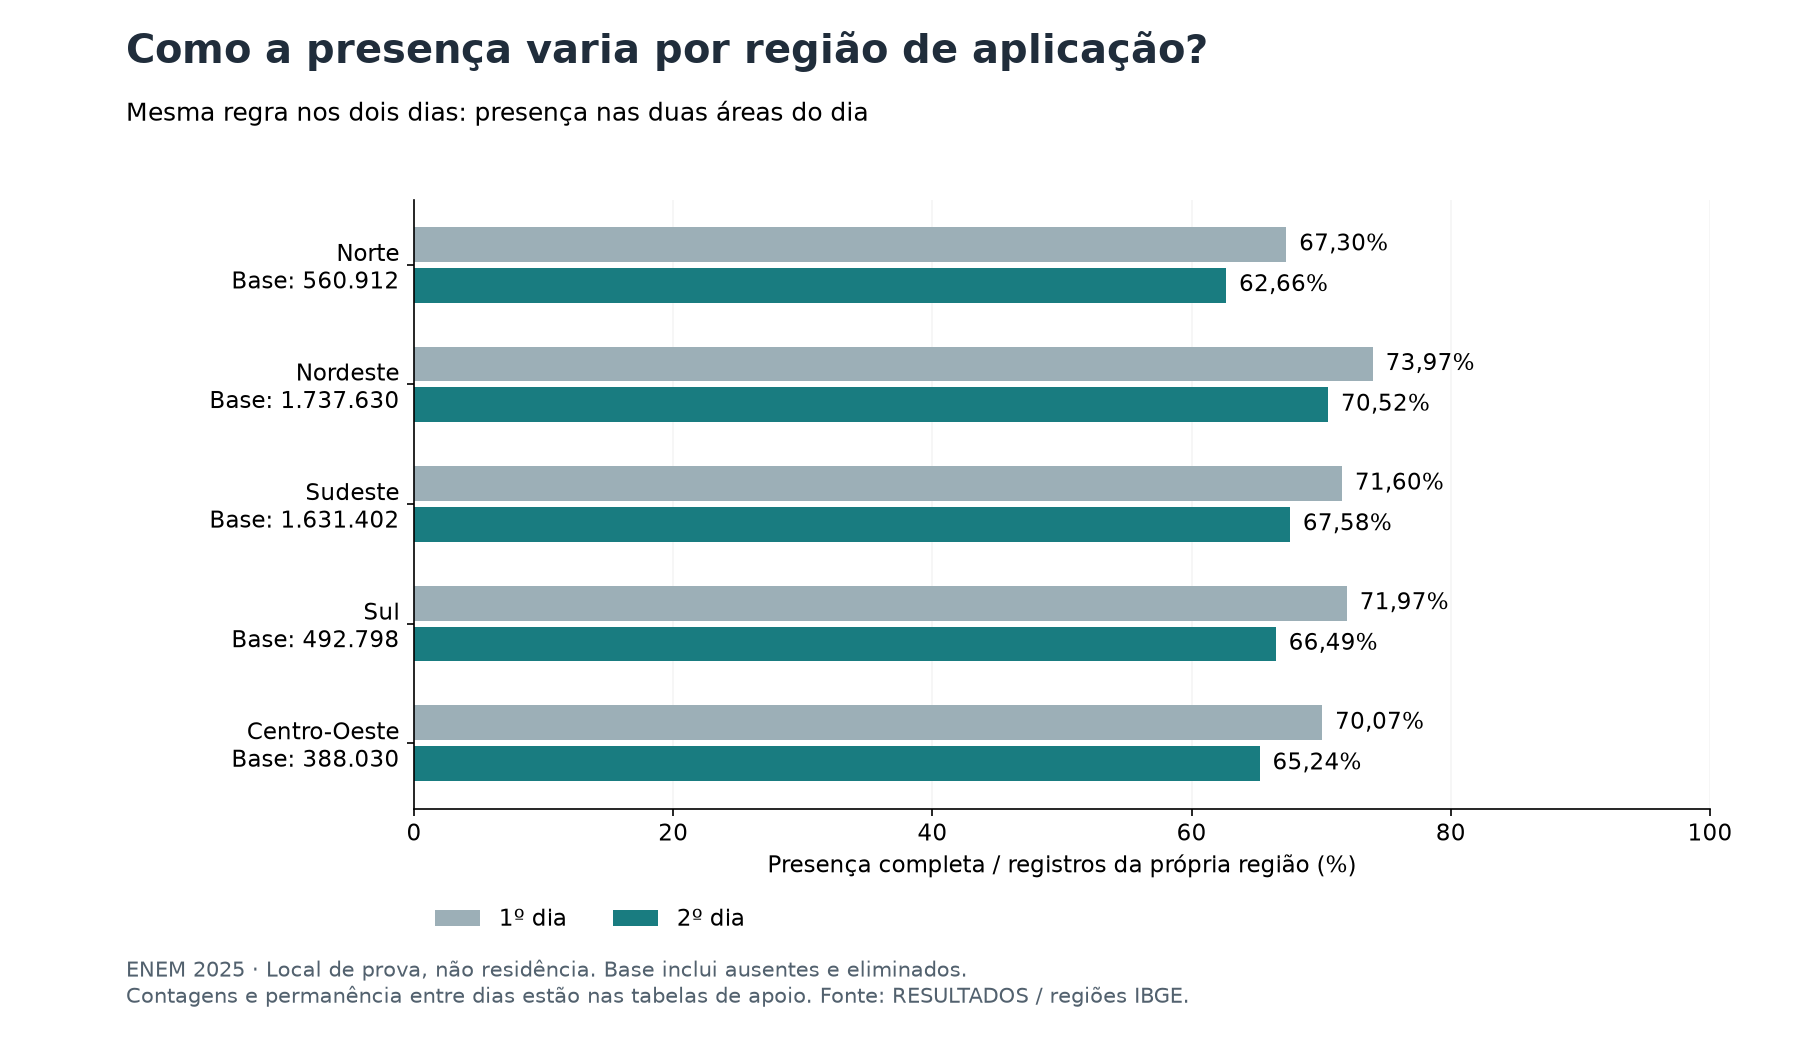

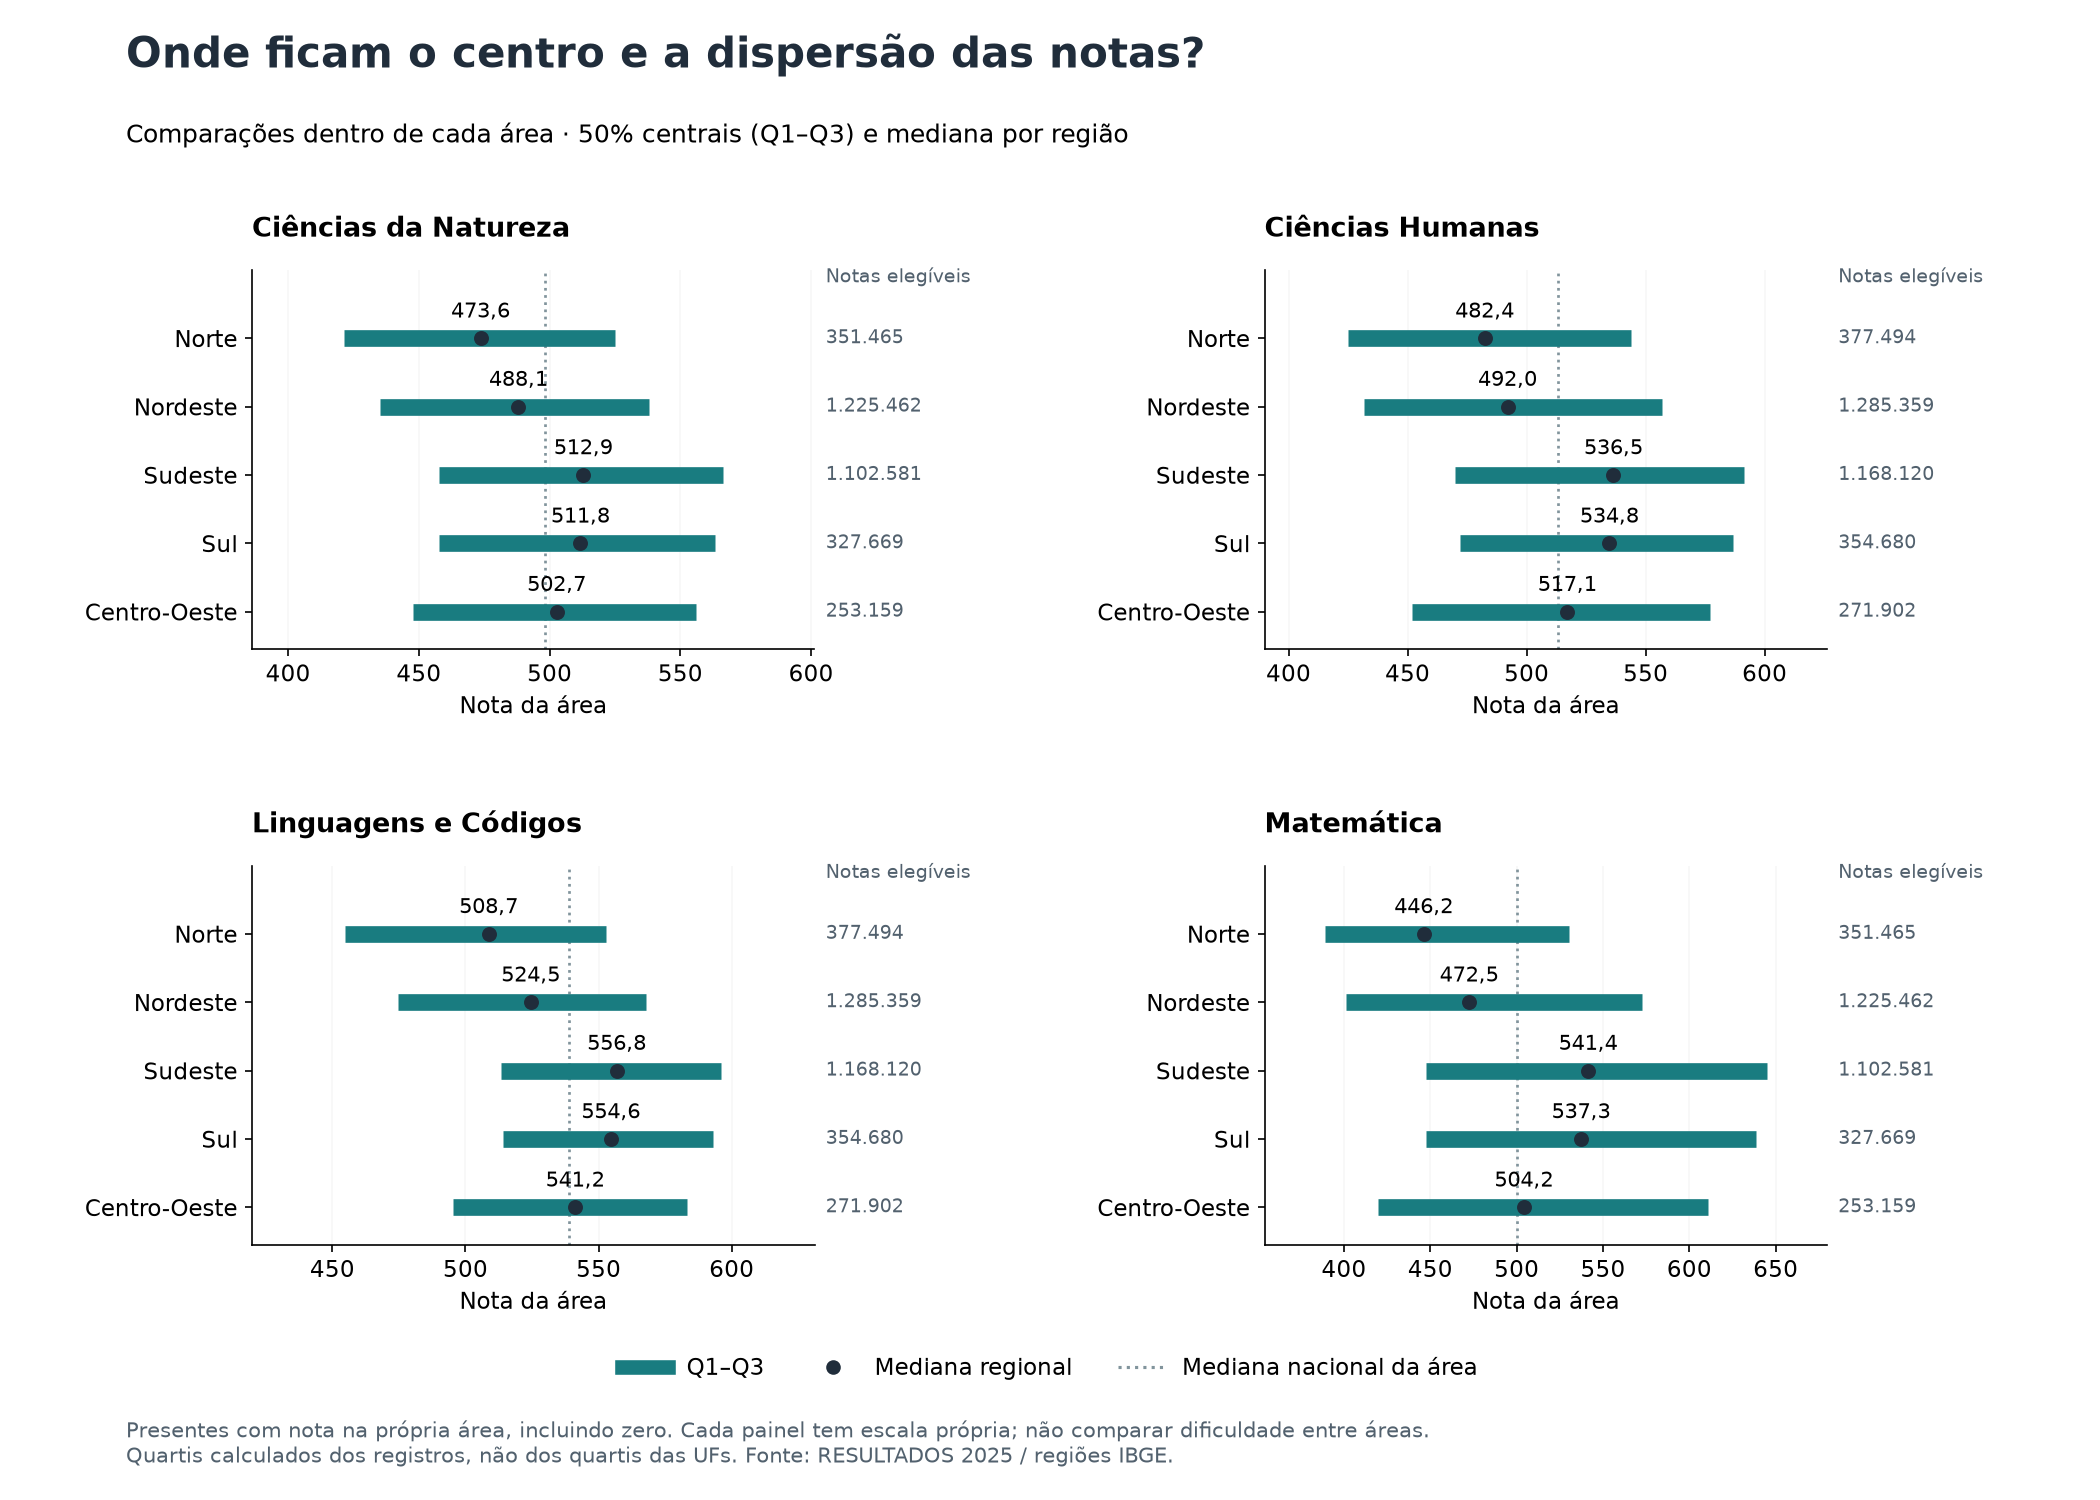

Trusted preservada; quatro CSVs e auditoria publicados.


In [5]:
figuras_local=gerar_graficos_local_prova(territorial,raiz/'apresentacao/graficos')
for figura in figuras_local:
    display(Image(filename=str(figura)))
print('Trusted preservada; quatro CSVs e auditoria publicados.')
